# Question 3: Support Vector Machine (SVM Classification) 

## 1. What is a hyperplane?

**Answer:**

A hyperplane is a decision boundary that separates data points into different classes.

### Explanation

- In 2D → it is a line  
- In 3D → it is a plane  
- In higher dimensions → it is called a hyperplane  

### Formula

w · x + b = 0

Where:
- w = weight vector  
- x = input features  
- b = bias  

### Conclusion

A hyperplane is used by SVM to separate classes in the feature space.

---

## 2. What is maximum margin?

**Answer:**

Maximum margin is the largest possible distance between the hyperplane and the nearest data points from both classes.

### Explanation

- The closest points to the boundary are called **support vectors**  
- SVM tries to maximize the distance between these points and the hyperplane  

### Formula

Margin = 2 / ||w||

### Key Idea

Larger margin → better generalization → less overfitting  

### Conclusion

SVM selects the hyperplane with the maximum margin for better performance.

---

## 3. What is the kernel trick?

**Answer:**

The kernel trick is a method used to transform data into a higher-dimensional space to make it linearly separable.

### Explanation

- Some data cannot be separated using a straight line  
- Kernel maps data into a higher dimension  
- In that space, separation becomes easier  

### Common Kernels

- Linear  
- Polynomial  
- RBF (Radial Basis Function)  

### Key Idea

No need to compute transformation explicitly — kernel does it efficiently.

### Conclusion

Kernel trick allows SVM to handle non-linear data.

---

## 4. Role of C (regularization parameter)

**Answer:**

C controls the trade-off between maximizing margin and minimizing classification error.

### Explanation

- It decides how much we penalize misclassification  

---

### High C → ?

- Small margin  
- Tries to classify all points correctly  
- Risk of overfitting  

---

### Low C → ?

- Large margin  
- Allows some misclassification  
- Better generalization  

---

### Summary Table

| C Value | Margin | Error Tolerance | Risk |
|--------|--------|----------------|------|
| High C | Small | Low | Overfitting |
| Low C | Large | High | Underfitting |

### Conclusion

C controls the balance between **accuracy and generalization** in SVM.

In [48]:
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.svm import SVC
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings

warnings.filterwarnings('ignore')


In [49]:
df = pd.read_csv('class_data.csv')
df

,X1,X2,Class
0,4.430008,6.099376,1
1,3.113289,5.319328,1
2,4.743076,3.897983,1
3,6.558222,2.736974,1
4,2.914449,4.947298,1
...,...,...,...
995,2.817098,5.558436,1
996,7.127762,3.756421,1
997,4.728880,2.350932,1
998,2.215578,3.532054,0


In [50]:
X = df[['X1','X2']]
y = df['Class']

In [51]:
svm1 = SVC(kernel="linear")
svm2 = SVC(kernel="rbf")

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
svm1.fit(X_train, y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [54]:
svm2.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [55]:
svm1_pred = svm1.predict(X_test)
svm2_pred = svm2.predict(X_test)


In [56]:
accuracy_svm1 = accuracy_score(y_test, svm1_pred)
accuracy_svm2 = accuracy_score(y_test, svm2_pred)

In [57]:
print("Linear SVM Accuracy:" ,accuracy_svm1)
print("RBF SVM Accuracy:  " ,accuracy_svm2)

Linear SVM Accuracy: 1.0
RBF SVM Accuracy:   0.97


In [60]:
X = X.to_numpy()

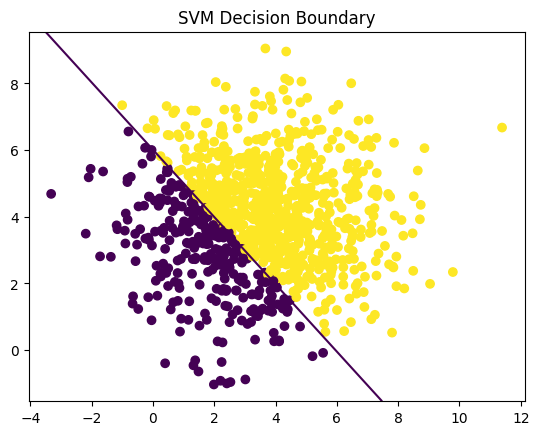

In [ ]:
plt.scatter(X[:,0], X[:,1], c=y)


ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

Z = svm1.decision_function(xy).reshape(XX.shape)

ax.contour(XX, YY, Z, levels=[0])

plt.title("SVM Decision Boundary")
plt.show()

In [ ]:
print("Class = " ,(svm1.predict([[4,4]]))[0])

Class =  1
